# RQ1 — Notebook 1: Dataset Pull

**Research Question**: Which clustering methods generate the best pseudo-labels for downstream classification?

This notebook builds the meta-training dataset pool from OpenML. The current run filtered 5,521 usable OpenML classification tasks down to **1,253 candidate datasets**, sampled 113 datasets for download/verification, and wrote a final manifest with **113 datasets**.

**Key filters**:
- 100 ≤ n_instances ≤ 100,000
- **2 ≤ n_classes ≤ 10** (binary included; clustering is meaningful for 2+ classes)
- **8 ≤ n_features < 200** on the loaded numeric columns
- **Missing value fraction ≤ 5%** (imputed downstream in notebook 02)
- Excludes the 9 held-out showcase datasets and 8 documented skip-list datasets

**Current manifest**:
- Class-count bins: 30 binary, 26 with 3–4 classes, 30 with 5–7 classes, 27 with 8–10 classes
- Feature range: 8–145 numeric features, median 25
- Feature types: 76 purely numerical datasets and 37 mixed-type datasets
- Missingness: 106 clean datasets and 7 datasets with 0–5% missing values
- Validation: 0 showcase leaks, 0 skip-list leaks, 23/24 active strata

**Outputs**:
- `data/meta_table/candidate_pool.csv` — full filtered candidate pool with metadata before sampling, shape `(1253, 16)`
- `data/meta_table/dataset_manifest.csv` — verified sampled manifest, shape `(113, 16)`
- `data/meta_table/manifest_diagnostics.txt` — validation and manifest diagnostics
- `outputs/figures/manifest_distributions.png` — class-bin and feature-count distributions


In [41]:
import os, sys, math, warnings
from datetime import datetime, timezone
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import openml

ROOT      = os.path.abspath(os.path.join(os.getcwd(), '..'))
RAW_DIR   = os.path.join(ROOT, 'data', 'raw')
META_DIR  = os.path.join(ROOT, 'data', 'meta_table')
MANIFEST  = os.path.join(META_DIR, 'dataset_manifest.csv')
CAND_POOL = os.path.join(META_DIR, 'candidate_pool.csv')
DIAG_FILE = os.path.join(META_DIR, 'manifest_diagnostics.txt')

os.makedirs(RAW_DIR,  exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

openml.config.cache_directory = RAW_DIR

print(f'ROOT      : {ROOT}')
print(f'MANIFEST  : {MANIFEST}')
print(f'CAND_POOL : {CAND_POOL}')

ROOT      : c:\MLResearch
MANIFEST  : c:\MLResearch\data\meta_table\dataset_manifest.csv
CAND_POOL : c:\MLResearch\data\meta_table\candidate_pool.csv


In [ ]:
# Showcase datasets: held-out generalization test — NEVER in meta-training
SHOWCASE_IDS = {
    61,    # iris
    187,   # wine
    15,    # breast-w
    53,    # heart-statlog
    40966, # penguins
    37,    # diabetes
    54,    # vehicle
    1590,  # adult
    1597,  # creditcard
    # Added in the RQ4 showcase expansion (rq4_generalization/07_showcase_eval.ipynb)
    # to strengthen the held-out generalization evaluation beyond 9 datasets.
    # Each was checked against dataset_manifest.csv by name AND (n_instances,
    # n_classes) to rule out a same-data/different-id duplicate of a training set.
    59,    # ionosphere
    182,   # satimage
    30,    # page-blocks -- swapped in for Texture (id=40499): Texture has 11
           # classes, violating our own 2<=n_classes<=10 inclusion criterion
           # (confirmed against dataset_manifest.csv, training max is 10).
           # Page Blocks (n=5473, d=10, k=5, 0% missing) is comfortably in-bounds
           # and confirmed absent from dataset_manifest.csv by name and (n,k).
    28,    # optdigits
    44,    # spambase
}

# Skip IDs: reason string is mandatory for every entry.
# Never add a bare ID without a reason — the reason is the audit trail.
SKIP_IDS = {
    40685: "DBSCAN timeout >5min — distance matrix too large",
    46536: "DBSCAN timeout >5min — high-density structure causes excessive iterations",
    41166: "Memory error during agglomerative clustering linkage computation",
    255:   "Known data quality issue — duplicate rows after label encoding",
    119:   "Autoencoder training instability — loss diverges to NaN on multiple seeds",
    46955: "Clustering timeout — effective row count exceeds practical limit",
    45548: "Missing value fraction >50% after numeric-only column selection",
    45927: "Target column ambiguous — multiple valid target attributes in schema",
}

EXCLUDE_IDS = SHOWCASE_IDS | set(SKIP_IDS.keys())

print(f'Showcase IDs  : {sorted(SHOWCASE_IDS)}')
print(f'Skip IDs      : {sorted(SKIP_IDS.keys())}')
print(f'Total excluded: {len(EXCLUDE_IDS)}')
print()
for did, reason in sorted(SKIP_IDS.items()):
    print(f'  {did}: {reason}')

In [43]:
MIN_INSTANCES    = 100
MAX_INSTANCES    = 100_000
MIN_CLASSES      = 2
MAX_CLASSES      = 10
MIN_FEATURES     = 8       # raised from 5 — removes most toy low-dimensional datasets
MAX_FEATURES     = 200
MAX_MISSING_FRAC = 0.05

TARGET_COUNT         = 100
TARGET_PER_CLASS_BIN = 25
BIN_CAP              = 30   # hard cap per class_count_bin — prevents binary from dominating
STRATUM_FLOOR        = 4    # minimum per sub-stratum
STRATUM_CAP          = 8    # maximum per sub-stratum

CLASS_BIN_ORDER = ['binary', '3-4', '5-7', '8-10']

def assign_class_bin(n_classes):
    if n_classes == 2:
        return 'binary'
    elif n_classes <= 4:
        return '3-4'
    elif n_classes <= 7:
        return '5-7'
    else:
        return '8-10'

print('Filters:')
print(f'  instances     : {MIN_INSTANCES:,} – {MAX_INSTANCES:,}')
print(f'  classes       : {MIN_CLASSES} – {MAX_CLASSES}')
print(f'  features      : {MIN_FEATURES} – {MAX_FEATURES - 1}')
print(f'  missing frac  : <= {MAX_MISSING_FRAC:.0%}')
print(f'  bin cap       : {BIN_CAP} per class_count_bin')
print(f'  stratum       : floor={STRATUM_FLOOR},  cap={STRATUM_CAP}')

Filters:
  instances     : 100 – 100,000
  classes       : 2 – 10
  features      : 8 – 199
  missing frac  : <= 5%
  bin cap       : 30 per class_count_bin
  stratum       : floor=4,  cap=8


In [44]:
print('Fetching task list from OpenML (~30 s on first run)...')
tasks = openml.tasks.list_tasks(
    task_type=openml.tasks.TaskType.SUPERVISED_CLASSIFICATION,
    output_format='dataframe',
)
print(f'Total tasks returned: {len(tasks):,}')

print('Fetching dataset-level metadata (~15 s on first run)...')
try:
    ds_meta = openml.datasets.list_datasets(output_format='dataframe')
    print(f'Dataset metadata: {len(ds_meta):,} entries')
except Exception as e:
    print(f'Warning: could not fetch dataset list ({e})')
    print('version and feature-type columns will be NA')
    ds_meta = pd.DataFrame(columns=['did'])

Fetching task list from OpenML (~30 s on first run)...
Total tasks returned: 5,582
Fetching dataset-level metadata (~15 s on first run)...
Dataset metadata: 6,407 entries


In [45]:
df = tasks.copy()

needed = ['NumberOfInstances', 'NumberOfFeatures', 'NumberOfClasses',
          'NumberOfMissingValues', 'did']
df = df.dropna(subset=needed)
for col in needed[:-1]:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=needed)

# Compute missing value fraction from OpenML metadata
total_cells = df['NumberOfInstances'] * df['NumberOfFeatures']
df['missing_value_fraction'] = (
    df['NumberOfMissingValues'] / total_cells
).fillna(0).clip(0, 1)

before = len(df)
df = df[
    (df['NumberOfInstances']      >= MIN_INSTANCES)     &
    (df['NumberOfInstances']      <= MAX_INSTANCES)     &
    (df['NumberOfClasses']        >= MIN_CLASSES)       &
    (df['NumberOfClasses']        <= MAX_CLASSES)       &
    (df['NumberOfFeatures']       >= MIN_FEATURES)      &
    (df['NumberOfFeatures']       <  MAX_FEATURES)      &
    (df['missing_value_fraction'] <= MAX_MISSING_FRAC)
]
print(f'After filters: {len(df):,}  (from {before:,})')

df = df.drop_duplicates(subset='did')
df = df[~df['did'].isin(EXCLUDE_IDS)]
df = df.sort_values('NumberOfInstances').reset_index(drop=True)
print(f'After dedup + exclusions: {len(df):,} candidate datasets')

After filters: 2,548  (from 5,521)
After dedup + exclusions: 1,253 candidate datasets


In [46]:
# Enrich candidates with dataset-level metadata from OpenML
# and compute all stratification columns used for sampling.

if len(ds_meta) > 0:
    avail_cols = [c for c in ['did', 'version', 'NumberOfNumericFeatures',
                               'NumberOfSymbolicFeatures'] if c in ds_meta.columns]
    ds_sub = ds_meta[avail_cols].drop_duplicates(subset='did')
    df = df.merge(ds_sub, on='did', how='left')

df['openml_version']      = df['version'].fillna('') if 'version' in df.columns else ''
df['n_numerical_features'] = pd.to_numeric(
    df.get('NumberOfNumericFeatures', pd.Series(dtype=float)), errors='coerce')
df['n_categorical_features'] = pd.to_numeric(
    df.get('NumberOfSymbolicFeatures', pd.Series(dtype=float)), errors='coerce')

# Class balance ratio from task metadata
if 'MinorityClassSize' in df.columns and 'MajorityClassSize' in df.columns:
    df['class_balance_ratio'] = (
        pd.to_numeric(df['MinorityClassSize'], errors='coerce') /
        pd.to_numeric(df['MajorityClassSize'], errors='coerce').replace(0, float('nan'))
    ).clip(0, 1).fillna(0.0)
else:
    df['class_balance_ratio'] = 0.0

# Class-count bin (4 balanced bins)
df['class_count_bin'] = df['NumberOfClasses'].apply(assign_class_bin)

# Size bin from log10(n_instances)
df['log_n'] = np.log10(df['NumberOfInstances'])
size_cut = pd.cut(df['log_n'], bins=3, labels=False).fillna(0).astype(int)
df['size_bin'] = size_cut.map({0: 'small', 1: 'medium', 2: 'large'})

# Balance bin
df['balance_bin'] = df['class_balance_ratio'].gt(0.5).map(
    {True: 'balanced', False: 'imbalanced'}
)

# 24-cell stratum key
df['stratum'] = (df['class_count_bin'] + '_' + df['size_bin'] + '_' + df['balance_bin'])

# Standardise column names for downstream use
df = df.rename(columns={
    'did':                  'dataset_id',
    'NumberOfInstances':    'n_instances',
    'NumberOfFeatures':     'n_features',
    'NumberOfClasses':      'n_classes',
    'NumberOfMissingValues':'n_missing_values',
})
df['openml_did'] = df['dataset_id']

print('=== Class-count bin distribution in candidate pool ===')
print(df['class_count_bin'].value_counts().reindex(CLASS_BIN_ORDER))
print(f'\nTotal candidates: {len(df):,}')
print()
print('=== Feature count distribution (post-filter) ===')
q = df['n_features'].describe(percentiles=[0.25, 0.5, 0.75])
print(q[['min', '25%', '50%', '75%', 'max']].round(0).to_string())
if q['50%'] < 20:
    print(f'\nWARNING: median features = {q["50%"]:.0f} < 20 — consider raising MIN_FEATURES')

=== Class-count bin distribution in candidate pool ===
class_count_bin
binary    932
3-4       114
5-7       134
8-10       73
Name: count, dtype: int64

Total candidates: 1,253

=== Feature count distribution (post-filter) ===
min      8.0
25%     12.0
50%     21.0
75%     40.0
max    183.0


In [47]:
# Save full candidate pool before sampling.
# This file lets you re-sample with different strata or counts
# without re-querying OpenML.

pool_cols = [
    'dataset_id', 'openml_did', 'name',
    'n_instances', 'n_features', 'n_classes', 'n_missing_values',
    'missing_value_fraction', 'n_numerical_features', 'n_categorical_features',
    'class_balance_ratio', 'openml_version',
    'class_count_bin', 'size_bin', 'balance_bin', 'stratum',
]
pool_cols = [c for c in pool_cols if c in df.columns]
df_pool = df[pool_cols].copy()
df_pool.to_csv(CAND_POOL, index=False)
print(f'Candidate pool saved -> {CAND_POOL}')
print(f'Shape: {df_pool.shape}')
print()
print('=== Strata coverage (of 24 possible strata) ===')
strata_summary = (
    df_pool.groupby(['class_count_bin', 'size_bin', 'balance_bin'])
    .size()
    .rename('count')
    .reset_index()
)
print(strata_summary.to_string(index=False))
print(f'\nStrata with data: {len(strata_summary)}/24')

Candidate pool saved -> c:\MLResearch\data\meta_table\candidate_pool.csv
Shape: (1253, 16)

=== Strata coverage (of 24 possible strata) ===
class_count_bin size_bin balance_bin  count
            3-4    large    balanced      3
            3-4    large  imbalanced     24
            3-4   medium    balanced     17
            3-4   medium  imbalanced     42
            3-4    small    balanced     12
            3-4    small  imbalanced     16
            5-7    large    balanced      4
            5-7    large  imbalanced     18
            5-7   medium    balanced     15
            5-7   medium  imbalanced     56
            5-7    small    balanced      3
            5-7    small  imbalanced     38
           8-10    large    balanced      1
           8-10    large  imbalanced      1
           8-10   medium    balanced     28
           8-10   medium  imbalanced     34
           8-10    small    balanced      2
           8-10    small  imbalanced      7
         binary    large

## Sampling Strategy

Sampling is stratified by class-count bin, log-size bin, and balance bin. The current run used a per-class-bin cap of 30, a sub-stratum floor of 4, and a sub-stratum cap of 8.

The initial sample selected **113 datasets**: 30 binary, 29 with 3–4 classes, 30 with 5–7 classes, and 24 with 8–10 classes. After download verification and replacement of failed datasets, the final manifest contains **113 datasets** with bin counts of 30, 26, 30, and 27 respectively.

**Formula**: `n_stratum = clamp(round(stratum_size / bin_pool × bin_target), STRATUM_FLOOR, STRATUM_CAP)`

If a stratum has fewer datasets than the floor, all available datasets are used. Replacement candidates are admitted only when their class-count bin is still below `BIN_CAP`.


In [48]:
frames = []

print(f'=== Per-bin sampling (cap={BIN_CAP} per class_count_bin) ===')
for class_bin in CLASS_BIN_ORDER:
    df_bin   = df[df['class_count_bin'] == class_bin]
    bin_avail  = len(df_bin)
    bin_target = min(BIN_CAP, bin_avail)

    if bin_avail == 0:
        print(f'  {class_bin:8s}  WARNING: no candidates')
        continue

    # Proportional across sub-strata within this bin
    sub_sizes    = df_bin.groupby('stratum').size()
    proportional = (sub_sizes / bin_avail * bin_target).round().astype(int)
    sub_targets  = proportional.clip(lower=STRATUM_FLOOR, upper=STRATUM_CAP)

    bin_frames = []
    for stratum_val, group in df_bin.groupby('stratum'):
        n_t = int(sub_targets.get(stratum_val, STRATUM_FLOOR))
        n_s = min(n_t, len(group))
        bin_frames.append(group.sample(n_s, random_state=42))

        zero_strata = [s for s, g in df_bin.groupby('stratum') if len(g) == 0]
    if zero_strata:
        print(f'  {class_bin:8s}  FLAG: empty sub-strata: {zero_strata}')

    bin_sample = pd.concat(bin_frames)
    if len(bin_sample) > BIN_CAP:
        bin_sample = bin_sample.sample(BIN_CAP, random_state=42)

    print(f'  {class_bin:8s}  pool={bin_avail:4d}  target={bin_target}  sampled={len(bin_sample)}')
    frames.append(bin_sample)

sampled = (pd.concat(frames)
             .sample(frac=1, random_state=42)
             .reset_index(drop=True))

print(f'\nSelected {len(sampled)} datasets for download and verification')
print()
print('=== Class-count bin counts in sample ===')
print(sampled['class_count_bin'].value_counts().reindex(CLASS_BIN_ORDER))

shortfalls = [
    f'{b}: {(sampled["class_count_bin"] == b).sum()} (below 20 minimum)'
    for b in CLASS_BIN_ORDER
    if (sampled['class_count_bin'] == b).sum() < 20
]
if shortfalls:
    print(f'\nWARNING — bins below 20: {shortfalls}')
else:
    print('\nAll class-count bins meet the >=20 minimum.')

=== Per-bin sampling (cap=30 per class_count_bin) ===
  binary    pool= 932  target=30  sampled=30
  3-4       pool= 114  target=30  sampled=29
  5-7       pool= 134  target=30  sampled=30
  8-10      pool=  73  target=30  sampled=24

Selected 113 datasets for download and verification

=== Class-count bin counts in sample ===
class_count_bin
binary    30
3-4       29
5-7       30
8-10      24
Name: count, dtype: int64

All class-count bins meet the >=20 minimum.


In [49]:
DOWNLOAD_TS = datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ')

records = []
failed  = []

for i, row in sampled.iterrows():
    did  = int(row['dataset_id'])
    name = row.get('name', '')
    try:
        ds = openml.datasets.get_dataset(
            did, download_data=True,
            download_qualities=True,
            download_features_meta_data=False,
        )
        X, y, _, _ = ds.get_data(
            dataset_format='dataframe',
            target=ds.default_target_attribute,
        )
        X_num = X.select_dtypes(include=[np.number])
        n_categorical = X.shape[1] - X_num.shape[1]
        n_numerical   = X_num.shape[1]

        # Enforce feature floor on actual numeric column count after loading.
        # filter-tasks uses OpenML's NumberOfFeatures (all columns); datasets
        # with many categoricals can slip through with fewer than MIN_FEATURES
        # numeric columns — reject them here.
        if n_numerical < MIN_FEATURES:
            failed.append((did, name,
                           f'only {n_numerical} numeric features after selection '
                           f'(min={MIN_FEATURES})'))
            continue

        if y is None or y.isnull().all():
            failed.append((did, name, 'no valid target column'))
            continue

        total_cells  = X_num.shape[0] * X_num.shape[1]
        n_missing    = int(X_num.isnull().sum().sum())
        missing_frac = n_missing / total_cells if total_cells > 0 else 0.0

        if missing_frac > MAX_MISSING_FRAC:
            failed.append((did, name, f'missing_frac={missing_frac:.3f} > {MAX_MISSING_FRAC} after load'))
            continue

        n_inst    = X_num.shape[0]
        n_feat    = X_num.shape[1]
        n_classes = int(y.nunique())

        val_counts = pd.Series(y).value_counts()
        class_balance_ratio = float(val_counts.min() / val_counts.max()) if len(val_counts) > 1 else 1.0

        records.append({
            'dataset_id'            : did,
            'openml_did'            : did,
            'name'                  : ds.name,
            'n_instances'           : n_inst,
            'n_features'            : n_feat,
            'n_classes'             : n_classes,
            'n_numerical_features'  : n_numerical,
            'n_categorical_features': n_categorical,
            'missing_value_fraction': round(missing_frac, 4),
            'class_balance_ratio'   : round(class_balance_ratio, 4),
            'class_count_bin'       : assign_class_bin(n_classes),
            'size_bin'              : row.get('size_bin', ''),
            'balance_bin'           : row.get('balance_bin', ''),
            'stratum'               : row.get('stratum', ''),
            'openml_version'        : row.get('openml_version', ''),
            'download_timestamp'    : DOWNLOAD_TS,
        })
        print(f'[{i+1:3d}/{len(sampled)}] OK  id={did:6d}  {ds.name[:38]:38s}  '
              f'{n_inst:6d}r x {n_feat:3d}c  {n_classes}cls  '
              f'miss={missing_frac:.1%}  bal={class_balance_ratio:.2f}')

    except Exception as e:
        failed.append((did, name, str(e)))
        print(f'[{i+1:3d}/{len(sampled)}] FAIL id={did}  {name}  — {e}')

print(f'\nLoaded: {len(records)}  Failed: {len(failed)}')

[  3/113] OK  id= 46850  hepatitis_c_virus_hcv_for_egyptian_pat    1385r x  28c  4cls  miss=0.0%  bal=0.92
[  5/113] OK  id= 41881  FOREX_chfjpy-hour-High                   43825r x  10c  2cls  miss=0.0%  bal=0.92
[  7/113] OK  id= 44507  steel-plates-fault_seed_4_nrows_2000_n    1941r x  27c  7cls  miss=0.0%  bal=0.08
[ 10/113] OK  id= 44227  South_Asian_Churn_dataset                 2000r x   9c  2cls  miss=0.0%  bal=1.00
[ 11/113] OK  id= 44624  mfeat-factors_seed_1_nrows_2000_nclass    2000r x 100c  10cls  miss=0.0%  bal=1.00
[ 12/113] OK  id= 41168  jannis                                   83733r x  54c  4cls  miss=0.0%  bal=0.04
[ 13/113] OK  id=  1465  breast-tissue                              106r x   9c  6cls  miss=0.0%  bal=0.64
[ 14/113] OK  id=  1549  autoUniv-au6-750                           750r x  37c  8cls  miss=0.0%  bal=0.35
[ 15/113] OK  id=   830  fri_c2_250_10                              250r x  10c  2cls  miss=0.0%  bal=0.57
[ 19/113] OK  id= 44744  shuttle_see

In [50]:
# Attempt to replace failed downloads with other datasets from the candidate pool.
# Replacements must respect BIN_CAP — if a bin is already full, no replacement
# is admitted for that bin even if other bins have capacity.

# Step 1: tally current per-bin counts from successful downloads
bin_counts_current = {}
for r in records:
    b = r.get('class_count_bin') or assign_class_bin(r.get('n_classes', 2))
    bin_counts_current[b] = bin_counts_current.get(b, 0) + 1

print('Per-bin counts entering replace-failed:')
for b in CLASS_BIN_ORDER:
    print(f'  {b:8s}: {bin_counts_current.get(b, 0):2d} / {BIN_CAP}')
print()

existing_ids = {r['dataset_id'] for r in records}
replacement_candidates = (
    df_pool[~df_pool['dataset_id'].isin(existing_ids | EXCLUDE_IDS)]
    .sort_values('n_instances')['dataset_id']
    .tolist()
)

for did_failed, name, reason in failed:
    failed_pool_row = df_pool[df_pool['dataset_id'] == did_failed]
    failed_bin = (
        failed_pool_row['class_count_bin'].iloc[0]
        if len(failed_pool_row) > 0 else 'unknown'
    )
    replaced = False

    for cand_id in replacement_candidates:
        if cand_id in existing_ids:
            continue
        try:
            ds = openml.datasets.get_dataset(
                cand_id, download_data=True,
                download_qualities=True,
                download_features_meta_data=False,
            )
            X, y, _, _ = ds.get_data(
                dataset_format='dataframe',
                target=ds.default_target_attribute,
            )
            X_num = X.select_dtypes(include=[np.number])
            n_categorical = X.shape[1] - X_num.shape[1]

            if X_num.shape[1] == 0 or y is None:
                continue

            total_cells  = X_num.shape[0] * X_num.shape[1]
            missing_frac = X_num.isnull().sum().sum() / total_cells if total_cells > 0 else 0.0
            if missing_frac > MAX_MISSING_FRAC:
                continue

            n_inst, n_feat = X_num.shape
            n_cls = int(y.nunique())

            if not (MIN_INSTANCES <= n_inst <= MAX_INSTANCES
                    and MIN_CLASSES <= n_cls <= MAX_CLASSES
                    and MIN_FEATURES <= n_feat < MAX_FEATURES):
                continue

            # Enforce BIN_CAP — skip candidate if its bin is already full
            cand_bin = assign_class_bin(n_cls)
            if bin_counts_current.get(cand_bin, 0) >= BIN_CAP:
                continue

            pool_row = df_pool[df_pool['dataset_id'] == cand_id]
            val_counts = pd.Series(y).value_counts()
            class_balance_ratio = float(val_counts.min() / val_counts.max()) if len(val_counts) > 1 else 1.0

            records.append({
                'dataset_id'            : cand_id,
                'openml_did'            : cand_id,
                'name'                  : ds.name,
                'n_instances'           : n_inst,
                'n_features'            : n_feat,
                'n_classes'             : n_cls,
                'n_numerical_features'  : n_feat,
                'n_categorical_features': n_categorical,
                'missing_value_fraction': round(missing_frac, 4),
                'class_balance_ratio'   : round(class_balance_ratio, 4),
                'class_count_bin'       : cand_bin,
                'size_bin'              : pool_row['size_bin'].iloc[0] if len(pool_row) else '',
                'balance_bin'           : pool_row['balance_bin'].iloc[0] if len(pool_row) else '',
                'stratum'               : pool_row['stratum'].iloc[0] if len(pool_row) else '',
                'openml_version'        : pool_row['openml_version'].iloc[0] if len(pool_row) else '',
                'download_timestamp'    : DOWNLOAD_TS,
            })
            existing_ids.add(cand_id)
            bin_counts_current[cand_bin] = bin_counts_current.get(cand_bin, 0) + 1
            replacement_candidates.remove(cand_id)
            print(f'  REPLACED  failed={did_failed} [{failed_bin}]'
                  f'  ->  id={cand_id} ({ds.name}) [{cand_bin}]'
                  f'  {n_inst}r x {n_feat}c  {n_cls}cls'
                  f'  miss={missing_frac:.1%}  bal={class_balance_ratio:.2f}'
                  f'  (bin now {bin_counts_current[cand_bin]}/{BIN_CAP})')
            replaced = True
            break
        except Exception:
            pass

    if not replaced:
        print(f'  NO REPLACEMENT  id={did_failed} ({name}) [{failed_bin}] — {reason}')

print()
print('Per-bin counts after replace-failed:')
for b in CLASS_BIN_ORDER:
    print(f'  {b:8s}: {bin_counts_current.get(b, 0):2d} / {BIN_CAP}')

Per-bin counts entering replace-failed:
  binary  : 23 / 30
  3-4     : 16 / 30
  5-7     : 22 / 30
  8-10    : 19 / 30

  REPLACED  failed=42169 [5-7]  ->  id=716 (fri_c3_100_50) [binary]  100r x 50c  2cls  miss=0.0%  bal=0.61  (bin now 24/30)
  REPLACED  failed=45068 [binary]  ->  id=775 (fri_c2_100_25) [binary]  100r x 25c  2cls  miss=0.0%  bal=0.75  (bin now 25/30)
  REPLACED  failed=46676 [5-7]  ->  id=768 (fri_c3_100_25) [binary]  100r x 25c  2cls  miss=0.0%  bal=0.82  (bin now 26/30)
  REPLACED  failed=44703 [3-4]  ->  id=762 (fri_c2_100_10) [binary]  100r x 10c  2cls  miss=0.0%  bal=0.82  (bin now 27/30)
  REPLACED  failed=46906 [5-7]  ->  id=812 (fri_c1_100_25) [binary]  100r x 25c  2cls  miss=0.0%  bal=0.89  (bin now 28/30)
  REPLACED  failed=46963 [3-4]  ->  id=808 (fri_c0_100_10) [binary]  100r x 10c  2cls  miss=0.0%  bal=0.82  (bin now 29/30)
  REPLACED  failed=1506 [binary]  ->  id=868 (fri_c4_100_25) [binary]  100r x 25c  2cls  miss=0.0%  bal=0.85  (bin now 30/30)
  REPL

In [51]:
manifest = pd.DataFrame(records)

if manifest.empty:
    raise RuntimeError('Manifest is empty — all downloads failed')

manifest_cols = [
    'dataset_id', 'openml_did', 'name',
    'n_instances', 'n_features', 'n_classes',
    'n_numerical_features', 'n_categorical_features',
    'missing_value_fraction', 'class_balance_ratio',
    'openml_version', 'download_timestamp',
    'class_count_bin', 'size_bin', 'balance_bin', 'stratum',
]
manifest_cols = [c for c in manifest_cols if c in manifest.columns]
manifest = manifest[manifest_cols]

# Sanity checks
leaked_showcase = set(manifest['dataset_id']) & SHOWCASE_IDS
leaked_skip     = set(manifest['dataset_id']) & set(SKIP_IDS.keys())
assert len(leaked_showcase) == 0, f'EXCLUSION LEAK (showcase): {leaked_showcase}'
assert len(leaked_skip)     == 0, f'EXCLUSION LEAK (skip):     {leaked_skip}'
assert manifest['dataset_id'].is_unique,  'Duplicate dataset IDs in manifest'

manifest.to_csv(MANIFEST, index=False)
print(f'Manifest saved -> {MANIFEST}')
print(f'Shape: {manifest.shape}')
print()
print('All sanity checks passed.')
print()
print('=== Class-count bin distribution ===')
print(manifest['class_count_bin'].value_counts().reindex(CLASS_BIN_ORDER))
print()
print('=== Feature count distribution ===')
feat_q = manifest['n_features'].describe(percentiles=[0.25, 0.5, 0.75])
print(feat_q[['min', '25%', '50%', '75%', 'max']].round(0).to_string())
print()
print(manifest.head(10).to_string(index=False))

Manifest saved -> c:\MLResearch\data\meta_table\dataset_manifest.csv
Shape: (113, 16)

All sanity checks passed.

=== Class-count bin distribution ===
class_count_bin
binary    30
3-4       26
5-7       30
8-10      27
Name: count, dtype: int64

=== Feature count distribution ===
min      8.0
25%     12.0
50%     25.0
75%     66.0
max    145.0

 dataset_id  openml_did                                                                     name  n_instances  n_features  n_classes  n_numerical_features  n_categorical_features  missing_value_fraction  class_balance_ratio  openml_version   download_timestamp class_count_bin size_bin balance_bin                stratum
      46850       46850                              hepatitis_c_virus_hcv_for_egyptian_patients         1385          28          4                    28                       0                     0.0               0.9171               2 2026-05-02T11:56:42Z             3-4   medium    balanced    3-4_medium_balanced
      41881

In [52]:
manifest = pd.read_csv(MANIFEST)

n_total      = len(manifest)
n_binary     = (manifest['class_count_bin'] == 'binary').sum()
n_34         = (manifest['class_count_bin'] == '3-4').sum()
n_57         = (manifest['class_count_bin'] == '5-7').sum()
n_810        = (manifest['class_count_bin'] == '8-10').sum()
n_purely_num = (manifest['n_categorical_features'].fillna(0) == 0).sum()
n_mixed      = ((manifest['n_categorical_features'].fillna(0) > 0) &
                (manifest['n_numerical_features'].fillna(0) > 0)).sum()
n_balanced   = (manifest['balance_bin'] == 'balanced').sum()
n_imbalanced = (manifest['balance_bin'] == 'imbalanced').sum()
n_clean      = (manifest['missing_value_fraction'] == 0).sum()
n_with_miss  = (manifest['missing_value_fraction'] > 0).sum()
strata_counts = manifest.groupby('stratum').size()

lines = [
    '=== Manifest Diagnostics ===',
    f'Total datasets       : {n_total}',
    f'Class distribution   : {n_binary} binary, {n_34} 3-4 class, {n_57} 5-7 class, {n_810} 8-10 class',
    f'Instance range       : {manifest["n_instances"].min():.0f} – {manifest["n_instances"].max():.0f}'
    f'  (median {manifest["n_instances"].median():.0f})',
    f'Feature range        : {manifest["n_features"].min():.0f} – {manifest["n_features"].max():.0f}'
    f'  (median {manifest["n_features"].median():.0f})',
    f'Feature types        : {n_purely_num} purely numerical, {n_mixed} mixed',
    f'Class balance        : {n_balanced} balanced (>0.5), {n_imbalanced} imbalanced (<=0.5)',
    f'Missing values       : {n_clean} datasets clean, {n_with_miss} with 0-5% missing',
    '',
    '=== Validation ===',
]

showcase_leaked = len(set(manifest['dataset_id']) & SHOWCASE_IDS)
skip_leaked     = len(set(manifest['dataset_id']) & set(SKIP_IDS.keys()))
lines.append(f'Showcase IDs in manifest : {showcase_leaked} (must be 0)')
lines.append(f'Skip IDs in manifest     : {skip_leaked} (must be 0)')
lines.append(f'Stratum counts (active)  : min={strata_counts.min()} '
             f'max={strata_counts.max()} mean={strata_counts.mean():.1f}')
empty_strata = 24 - len(strata_counts)
lines.append(f'Empty strata             : {empty_strata} of 24')

diag_text = '\n'.join(lines)
print(diag_text)

with open(DIAG_FILE, 'w') as f:
    f.write(diag_text + '\n')
print(f'\nDiagnostics saved -> {DIAG_FILE}')

assert showcase_leaked == 0, f'CRITICAL: showcase IDs in manifest: {set(manifest["dataset_id"]) & SHOWCASE_IDS}'
assert skip_leaked     == 0, f'CRITICAL: skip IDs in manifest: {set(manifest["dataset_id"]) & set(SKIP_IDS.keys())}'
assert empty_strata    < 12, f'More than half of 24 strata are empty — pool may be too sparse'

print('\nAll validation checks passed.')
print('Ready for 02_lse_computation.ipynb'
      ' (ensure SimpleImputer is added before re-running LSE loop)')

=== Manifest Diagnostics ===
Total datasets       : 113
Class distribution   : 30 binary, 26 3-4 class, 30 5-7 class, 27 8-10 class
Instance range       : 100 – 83733  (median 1080)
Feature range        : 8 – 145  (median 25)
Feature types        : 76 purely numerical, 37 mixed
Class balance        : 60 balanced (>0.5), 53 imbalanced (<=0.5)
Missing values       : 106 datasets clean, 7 with 0-5% missing

=== Validation ===
Showcase IDs in manifest : 0 (must be 0)
Skip IDs in manifest     : 0 (must be 0)
Stratum counts (active)  : min=1 max=13 mean=4.9
Empty strata             : 1 of 24

Diagnostics saved -> c:\MLResearch\data\meta_table\manifest_diagnostics.txt

All validation checks passed.
Ready for 02_lse_computation.ipynb (ensure SimpleImputer is added before re-running LSE loop)


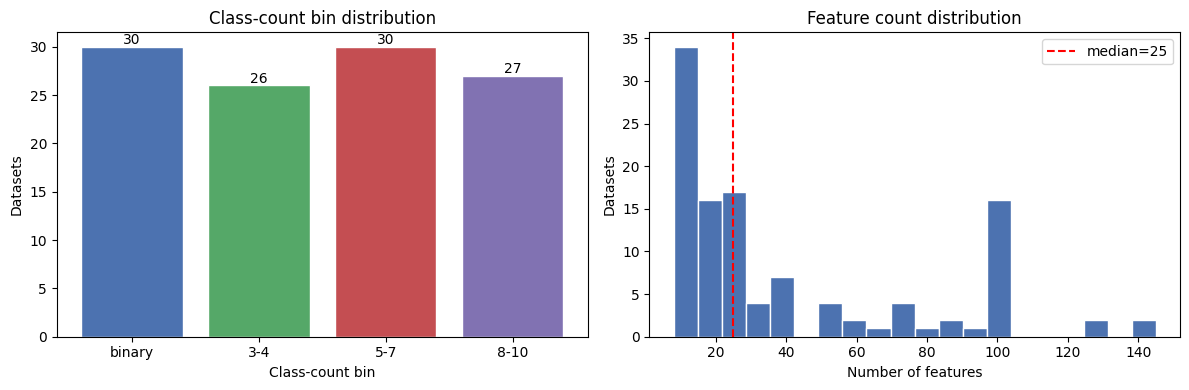

Saved -> c:\MLResearch\outputs\figures\manifest_distributions.png


In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: class-count bin distribution
bin_counts = manifest['class_count_bin'].value_counts().reindex(CLASS_BIN_ORDER, fill_value=0)
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
axes[0].bar(bin_counts.index, bin_counts.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Class-count bin')
axes[0].set_ylabel('Datasets')
axes[0].set_title('Class-count bin distribution')
for i, v in enumerate(bin_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=10)

# Plot 2: feature count histogram
axes[1].hist(manifest['n_features'], bins=20, color='#4C72B0', edgecolor='white')
median_feat = manifest['n_features'].median()
axes[1].axvline(median_feat, color='red', ls='--', lw=1.5, label=f'median={median_feat:.0f}')
axes[1].set_xlabel('Number of features')
axes[1].set_ylabel('Datasets')
axes[1].set_title('Feature count distribution')
axes[1].legend()

plt.tight_layout()
figs_dir = os.path.join(ROOT, 'outputs', 'figures')
os.makedirs(figs_dir, exist_ok=True)
path = os.path.join(figs_dir, 'manifest_distributions.png')
fig.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved -> {path}')